# <span style="color:#2F749F;"><strong>Sesión práctica 3: Codificación y transformación de variables</strong></span>

## **Datos de los estudiante**

Jose Miguel Correa - 1041631221

Camilo Mosquera Vega - 1103741046

In [ ]:
# Cargar dependencias
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import seaborn as sns
from sklearn.datasets import load_wine, fetch_california_housing, load_diabetes
from sklearn.preprocessing import StandardScaler, MinMaxScaler, RobustScaler, Normalizer, PowerTransformer
from mpl_toolkits.mplot3d import Axes3D
from scipy.stats import boxcox, skew

## <span style="color:#2F749F;"><strong>Ejercicio 1: Comparación de métodos de escalamiento</strong></span>

A partir de un conjunto de datos real sobre **vinos**, analiza cómo cambia la escala de las variables al aplicar diferentes métodos de **escalamiento de datos**, y compara visualmente sus efectos sobre la distribución.

1. Carga el conjunto de datos **wine** desde la librería `sklearn.datasets` usando `load_wine()`.

2. Convierte el conjunto de datos en un **DataFrame de pandas** e identifica las variables disponibles.

3. Selecciona al menos **tres variables numéricas** para el análisis (por ejemplo):
   - `alcohol`
   - `malic_acid`
   - `color_intensity`

4. Aplica los siguientes métodos de escalamiento sobre las variables seleccionadas:
   - `StandardScaler`
   - `MinMaxScaler`
   - `RobustScaler`
   - `Z-Score`

5. Genera **gráficas comparativas** que permitan visualizar la distribución de al menos **una de las variables seleccionadas** en los siguientes escenarios:
   - Distribución **original**
   - Distribución con **StandardScaler**
   - Distribución con **MinMaxScaler**
   - Distribución con **RobustScaler**
   - Distribución con **Z-Score**

6. Escribe un análisis de **máximo cinco líneas** en el que expliques las diferencias entre las técnicas o métodos, su impacto en los resultados y cuál consideras más recomendable, justificando brevemente tu elección.

In [ ]:
## importamos los datos
wine = load_wine()

  # Convertir a DataFrame
df = pd.DataFrame(wine.data, columns=wine.feature_names)

  # Agregar la variable objetivo (clase)
df["target"] = wine.target

  # Ver primeras filas
print(df.head())

   alcohol  malic_acid   ash  alcalinity_of_ash  magnesium  total_phenols  \
0    14.23        1.71  2.43               15.6      127.0           2.80   
1    13.20        1.78  2.14               11.2      100.0           2.65   
2    13.16        2.36  2.67               18.6      101.0           2.80   
3    14.37        1.95  2.50               16.8      113.0           3.85   
4    13.24        2.59  2.87               21.0      118.0           2.80   

   flavanoids  nonflavanoid_phenols  proanthocyanins  color_intensity   hue  \
0        3.06                  0.28             2.29             5.64  1.04   
1        2.76                  0.26             1.28             4.38  1.05   
2        3.24                  0.30             2.81             5.68  1.03   
3        3.49                  0.24             2.18             7.80  0.86   
4        2.69                  0.39             1.82             4.32  1.04   

   od280/od315_of_diluted_wines  proline  target  
0          

### Seleccion de variables numericas

Alcohol <p>
Magnesium <p>
hue <p>

In [ ]:
## Aplicamos los metodos de escalamiento
X = df[["alcohol", "magnesium", "hue"]]

In [ ]:

## 1. StandardScaler

scaler_standard = StandardScaler()
X_standard = scaler_standard.fit_transform(X)

df_standard = pd.DataFrame(X_standard, columns=X.columns)


## 2. MinMaxScaler

scaler_minmax = MinMaxScaler()
X_minmax = scaler_minmax.fit_transform(X)

df_minmax = pd.DataFrame(X_minmax, columns=X.columns)

## 3. RobustScaler
scaler_robust = RobustScaler()
X_robust = scaler_robust.fit_transform(X)

df_robust = pd.DataFrame(X_robust, columns=X.columns)

## 4. Z-Score (manual)

X_zscore = (X - X.mean()) / X.std()

df_zscore = pd.DataFrame(X_zscore, columns=X.columns)

## Ver resultados

print("Original:\n", X.head())
print("\nStandardScaler:\n", df_standard.head())
print("\nMinMaxScaler:\n", df_minmax.head())
print("\nRobustScaler:\n", df_robust.head())
print("\nZ-Score:\n", df_zscore.head())

Original:
    alcohol  magnesium   hue
0    14.23      127.0  1.04
1    13.20      100.0  1.05
2    13.16      101.0  1.03
3    14.37      113.0  0.86
4    13.24      118.0  1.04

StandardScaler:
     alcohol  magnesium       hue
0  1.518613   1.913905  0.362177
1  0.246290   0.018145  0.406051
2  0.196879   0.088358  0.318304
3  1.691550   0.930918 -0.427544
4  0.295700   1.281985  0.362177

MinMaxScaler:
     alcohol  magnesium       hue
0  0.842105   0.619565  0.455285
1  0.571053   0.326087  0.463415
2  0.560526   0.336957  0.447154
3  0.878947   0.467391  0.308943
4  0.581579   0.521739  0.455285

RobustScaler:
     alcohol  magnesium       hue
0  0.897338   1.526316  0.222222
1  0.114068   0.105263  0.251852
2  0.083650   0.157895  0.192593
3  1.003802   0.789474 -0.311111
4  0.144487   1.052632  0.222222

Z-Score:
     alcohol  magnesium       hue
0  1.514341   1.908522  0.361158
1  0.245597   0.018094  0.404908
2  0.196325   0.088110  0.317409
3  1.686791   0.928300 -0.426341
4

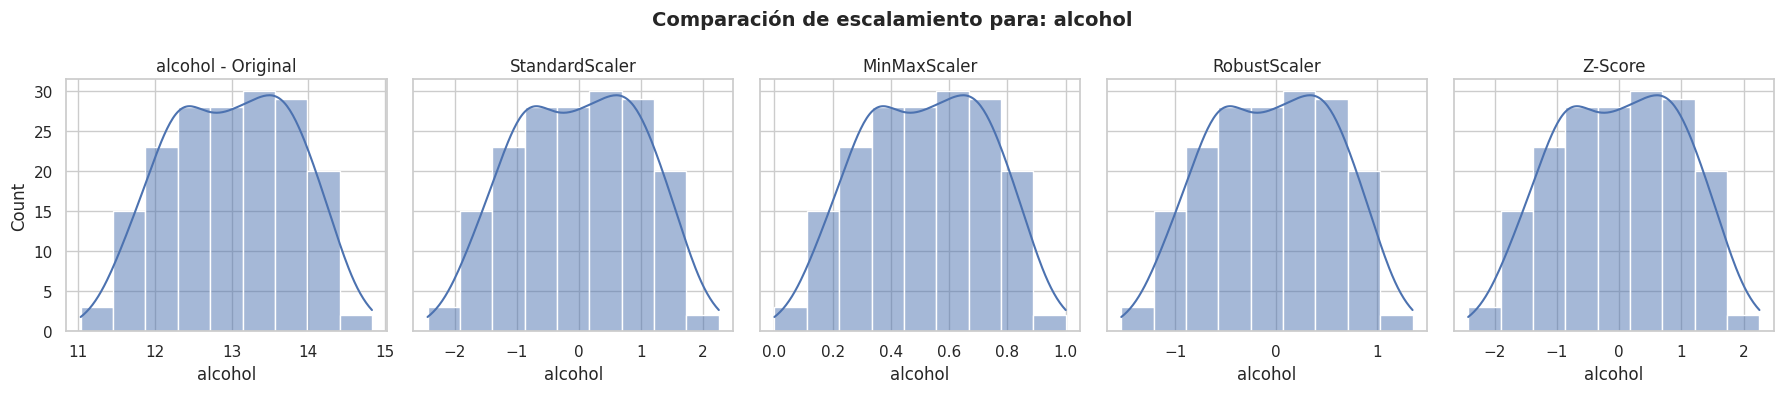

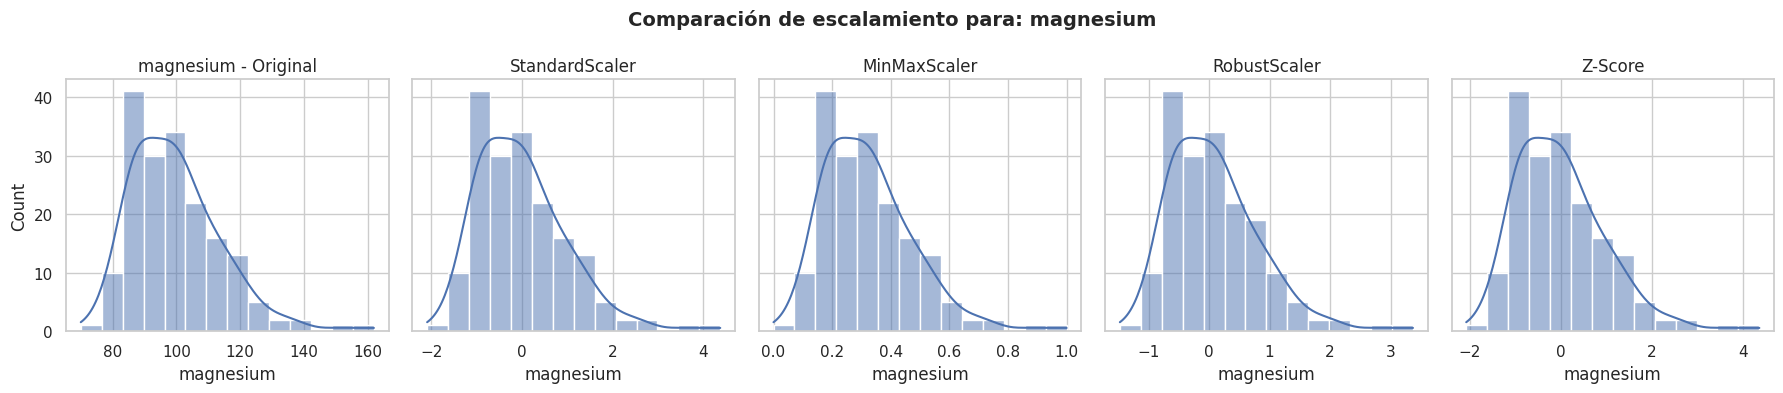

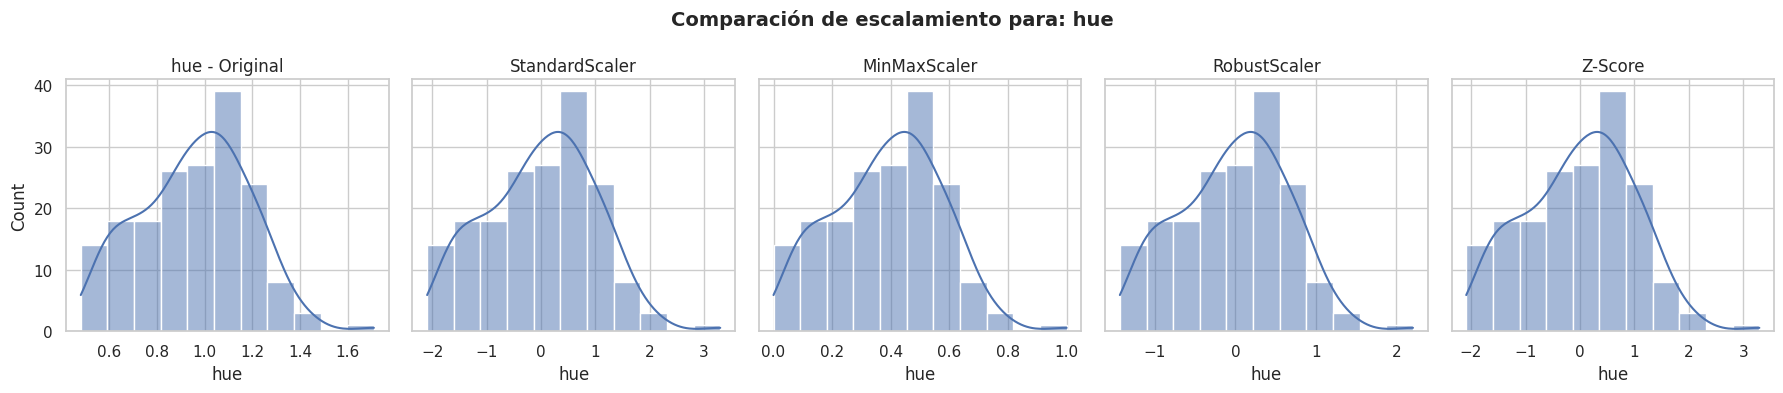

In [ ]:


sns.set_theme(style="whitegrid")

# 🔹 Escoge aquí las variables que quieras analizar
variables = ["alcohol", "magnesium", "hue"]
for var in variables:

    fig, axes = plt.subplots(1, 5, figsize=(18, 4), sharey=True)

    # Original
    sns.histplot(X[var], kde=True, ax=axes[0])
    axes[0].set_title(f"{var} - Original")

    # StandardScaler
    sns.histplot(df_standard[var], kde=True, ax=axes[1])
    axes[1].set_title("StandardScaler")

    # MinMaxScaler
    sns.histplot(df_minmax[var], kde=True, ax=axes[2])
    axes[2].set_title("MinMaxScaler")

    # RobustScaler
    sns.histplot(df_robust[var], kde=True, ax=axes[3])
    axes[3].set_title("RobustScaler")

    # Z-Score
    sns.histplot(df_zscore[var], kde=True, ax=axes[4])
    axes[4].set_title("Z-Score")

    plt.suptitle(f"Comparación de escalamiento para: {var}", fontsize=14, fontweight="bold")
    plt.tight_layout()
    plt.show()

##Analisis de las graficas:

Los metodos de escalamiento, no cambiaron la forma de distribución de los datos, solo cambió la escala en la que los vemos, lo que nos permite que las variables queden en magnitudes similares y no haya una que domine por sus numeros grandes como el magnesium en comparacion al hue, que es el objetivo del escalamiento

## <span style="color:#2F749F;"><strong>Ejercicio 2: Comparación de escalamiento RobustScaler vs Z-Score</strong></span>

A partir de un conjunto de datos real sobre **diabetes**, analiza cómo cambia la escala de las variables al aplicar **estandarización con Z-Score** y **escalamiento robusto**, y compara visualmente sus efectos cuando existen **posibles valores atípicos**.

1. Carga el conjunto de datos **diabetes** desde la librería `sklearn.datasets` usando `load_diabetes()`.

2. Convierte el conjunto de datos en un **DataFrame de pandas** e identifica las variables disponibles.

3. Selecciona al menos **tres variables numéricas** para el análisis (por ejemplo: `bmi`, `bp`, `s5` u otras disponibles en el dataset).

4. Aplica los siguientes métodos de escalamiento sobre las variables seleccionadas:
   - **StandardScaler** (Z-Score).
   - **RobustScaler** (basado en mediana e IQR).

5. Genera **gráficas comparativas** que permitan visualizar la distribución de al menos **una de las variables seleccionadas** en los siguientes escenarios:
   - Distribución **original**
   - Distribución **escalada con Z-Score**
   - Distribución **escalada con RobustScaler**

6. Escribe un análisis de **máximo cinco líneas** en el que expliques las diferencias entre las técnicas o métodos, su impacto en los resultados y cuál consideras más recomendable, justificando brevemente tu elección.

In [2]:
from sklearn.datasets import load_diabetes
import pandas as pd

# Cargar dataset
diabetes = load_diabetes()

# Convertir a DataFrame
df = pd.DataFrame(diabetes.data, columns=diabetes.feature_names)

# Agregar variable objetivo
df['target'] = diabetes.target

# Ver primeras filas
df.head()

,age,sex,bmi,bp,s1,s2,s3,s4,s5,s6,target
0,0.038076,0.050680,0.061696,0.021872,-0.044223,-0.034821,-0.043401,-0.002592,0.019907,-0.017646,151.0
1,-0.001882,-0.044642,-0.051474,-0.026328,-0.008449,-0.019163,0.074412,-0.039493,-0.068332,-0.092204,75.0
2,0.085299,0.050680,0.044451,-0.005670,-0.045599,-0.034194,-0.032356,-0.002592,0.002861,-0.025930,141.0
3,-0.089063,-0.044642,-0.011595,-0.036656,0.012191,0.024991,-0.036038,0.034309,0.022688,-0.009362,206.0
4,0.005383,-0.044642,-0.036385,0.021872,0.003935,0.015596,0.008142,-0.002592,-0.031988,-0.046641,135.0


In [4]:
from sklearn.preprocessing import StandardScaler, RobustScaler

# Variables seleccionadas
variables = ["bmi", "bp", "s5"]
X = df[variables].copy()

# Escalamiento
scaler_standard = StandardScaler()
scaler_robust = RobustScaler()

X_standard = scaler_standard.fit_transform(X)
X_robust = scaler_robust.fit_transform(X)

# Convertir a DataFrame para conservar nombres de columnas
df_standard = pd.DataFrame(X_standard, columns=variables)
df_robust = pd.DataFrame(X_robust, columns=variables)

print("Datos originales:")
print(X.head(), "\n")

print("Datos con StandardScaler:")
print(df_standard.head(), "\n")

print("Datos con RobustScaler:")
print(df_robust.head())

Datos originales:
        bmi        bp        s5
0  0.061696  0.021872  0.019907
1 -0.051474 -0.026328 -0.068332
2  0.044451 -0.005670  0.002861
3 -0.011595 -0.036656  0.022688
4 -0.036385  0.021872 -0.031988 

Datos con StandardScaler:
        bmi        bp        s5
0  1.297088  0.459841  0.418531
1 -1.082180 -0.553505 -1.436589
2  0.934533 -0.119214  0.060156
3 -0.243771 -0.770650  0.476983
4 -0.764944  0.459841 -0.672502 

Datos con RobustScaler:
        bmi        bp        s5
0  1.053498  0.380952  0.332755
1 -0.674897 -0.285714 -1.010756
2  0.790123  0.000000  0.073213
3 -0.065844 -0.428571  0.375087
4 -0.444444  0.380952 -0.457391


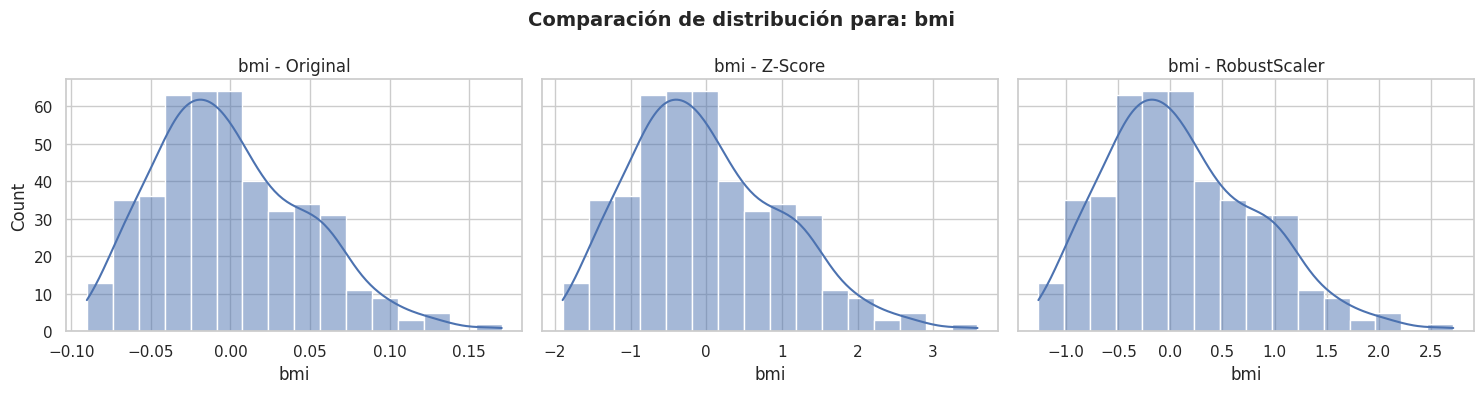

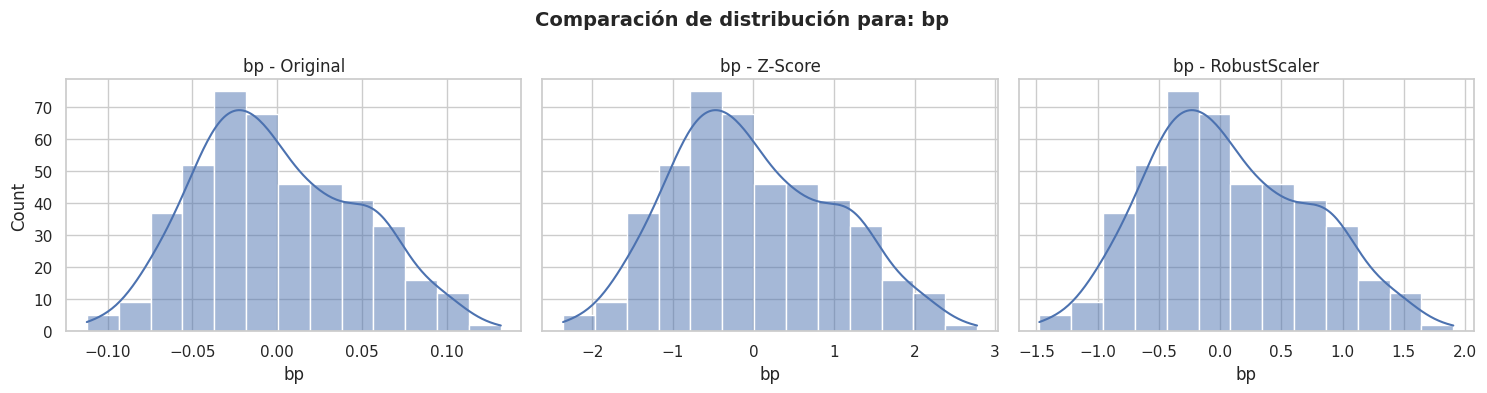

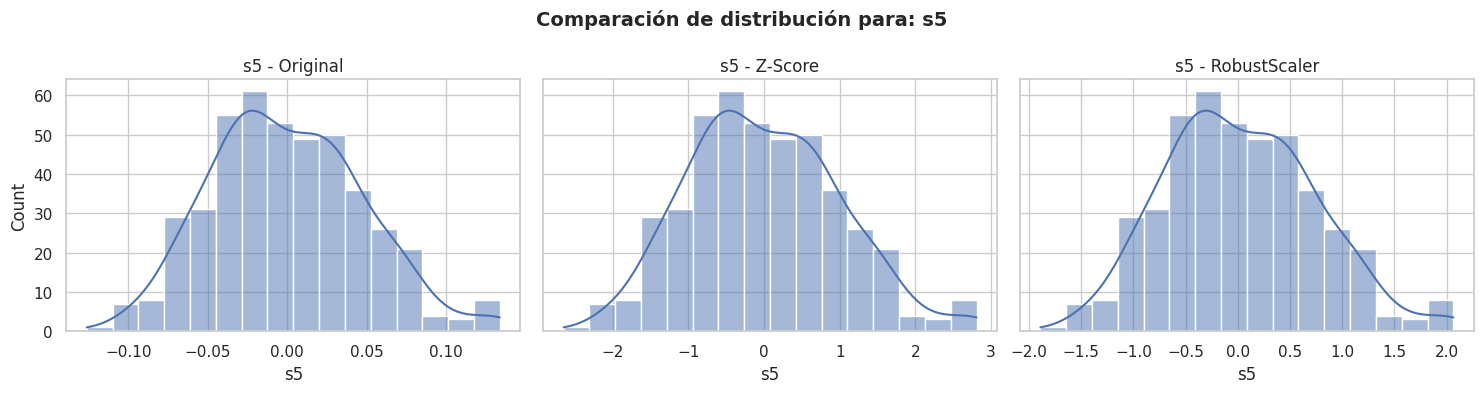

In [5]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
from sklearn.datasets import load_diabetes
from sklearn.preprocessing import StandardScaler, RobustScaler

# Cargar dataset
diabetes = load_diabetes()
df = pd.DataFrame(diabetes.data, columns=diabetes.feature_names)

# Variables seleccionadas
variables = ["bmi", "bp", "s5"]
X = df[variables].copy()

# Escalamiento
scaler_standard = StandardScaler()
scaler_robust = RobustScaler()

X_standard = scaler_standard.fit_transform(X)
X_robust = scaler_robust.fit_transform(X)

# Convertir a DataFrame para conservar nombres de columnas
df_standard = pd.DataFrame(X_standard, columns=variables)
df_robust = pd.DataFrame(X_robust, columns=variables)

# Estilo de gráficas
sns.set_theme(style="whitegrid")

# Graficar una figura por cada variable
for var in variables:

    fig, axes = plt.subplots(1, 3, figsize=(15, 4), sharey=True)

    # Original
    sns.histplot(X[var], kde=True, ax=axes[0])
    axes[0].set_title(f"{var} - Original")

    # StandardScaler (Z-Score)
    sns.histplot(df_standard[var], kde=True, ax=axes[1])
    axes[1].set_title(f"{var} - Z-Score")

    # RobustScaler
    sns.histplot(df_robust[var], kde=True, ax=axes[2])
    axes[2].set_title(f"{var} - RobustScaler")

    plt.suptitle(f"Comparación de distribución para: {var}", fontsize=14, fontweight="bold")
    plt.tight_layout()
    plt.show()


##Analisis:
Z-Score centra con la media y escala con la desviación estándar, mientras que RobustScaler usa la mediana y el IQR, por eso sus rangos no quedan iguales. En estas gráficas no se aprecian outliers extremos muy marcados, así que visualmente ambos métodos producen resultados bastante parecidos. Aun así, RobustScaler sería más conveniente si hubiera valores atípicos, porque sería menos sensible a ellos.

## **Ejercicio 3: Comparación de normalización L1 y L2**

**Dataset:** California Housing (sklearn.datasets - fetch_california_housing)

**Variables seleccionadas:** `MedInc`, `HouseAge`, `AveRooms`, `AveBedrms`, `AveOccup`

### **Código:**

In [ ]:
# Cargar dataset
housing = fetch_california_housing()
df = pd.DataFrame(housing.data, columns=housing.feature_names)

print("Columnas disponibles:", list(df.columns))
print("\nPrimeras filas del dataset:")
print(df.head())
print("\nDescripción estadística general:")
print(df.describe())

Columnas disponibles: ['MedInc', 'HouseAge', 'AveRooms', 'AveBedrms', 'Population', 'AveOccup', 'Latitude', 'Longitude']

Primeras filas del dataset:
   MedInc  HouseAge  AveRooms  AveBedrms  Population  AveOccup  Latitude  \
0  8.3252      41.0  6.984127   1.023810       322.0  2.555556     37.88   
1  8.3014      21.0  6.238137   0.971880      2401.0  2.109842     37.86   
2  7.2574      52.0  8.288136   1.073446       496.0  2.802260     37.85   
3  5.6431      52.0  5.817352   1.073059       558.0  2.547945     37.85   
4  3.8462      52.0  6.281853   1.081081       565.0  2.181467     37.85   

   Longitude  
0    -122.23  
1    -122.22  
2    -122.24  
3    -122.25  
4    -122.25  

Descripción estadística general:
             MedInc      HouseAge      AveRooms     AveBedrms    Population  \
count  20640.000000  20640.000000  20640.000000  20640.000000  20640.000000   
mean       3.870671     28.639486      5.429000      1.096675   1425.476744   
std        1.899822     12.58555

In [ ]:
# Selección de variables
variables = ['MedInc', 'HouseAge', 'AveRooms', 'AveBedrms', 'AveOccup']
X = df[variables].copy()

print(f"Variables seleccionadas: {variables}")
print("\nDistribución original:")
print(X.describe())

Variables seleccionadas: ['MedInc', 'HouseAge', 'AveRooms', 'AveBedrms', 'AveOccup']

Distribución original:
             MedInc      HouseAge      AveRooms     AveBedrms      AveOccup
count  20640.000000  20640.000000  20640.000000  20640.000000  20640.000000
mean       3.870671     28.639486      5.429000      1.096675      3.070655
std        1.899822     12.585558      2.474173      0.473911     10.386050
min        0.499900      1.000000      0.846154      0.333333      0.692308
25%        2.563400     18.000000      4.440716      1.006079      2.429741
50%        3.534800     29.000000      5.229129      1.048780      2.818116
75%        4.743250     37.000000      6.052381      1.099526      3.282261
max       15.000100     52.000000    141.909091     34.066667   1243.333333


In [ ]:
# Aplicar normalización L1
normalizer_l1 = Normalizer(norm='l1')
X_l1 = pd.DataFrame(
    normalizer_l1.fit_transform(X),
    columns=[f"{col}_L1" for col in variables]
)

# Aplicar normalización L2
normalizer_l2 = Normalizer(norm='l2')
X_l2 = pd.DataFrame(
    normalizer_l2.fit_transform(X),
    columns=[f"{col}_L2" for col in variables]
)

# Imprimir estadística luego de normalizar
print("Estadísticas tras normalización L1:")
print(X_l1.describe())

print("\nEstadísticas tras normalización L2:")
print(X_l2.describe())

Estadísticas tras normalización L1:
          MedInc_L1   HouseAge_L1   AveRooms_L1  AveBedrms_L1   AveOccup_L1
count  20640.000000  20640.000000  20640.000000  20640.000000  20640.000000
mean       0.100922      0.650815      0.142308      0.028862      0.077092
std        0.057648      0.143181      0.066399      0.012656      0.035876
min        0.007572      0.031355      0.002431      0.000640      0.011559
25%        0.059819      0.578443      0.096309      0.020436      0.053984
50%        0.086323      0.689933      0.123913      0.025117      0.070594
75%        0.128339      0.754723      0.173516      0.033735      0.092636
max        0.470383      0.912914      0.691741      0.164078      0.954531

Estadísticas tras normalización L2:
          MedInc_L2   HouseAge_L2   AveRooms_L2  AveBedrms_L2   AveOccup_L2
count  20640.000000  20640.000000  20640.000000  20640.000000  20640.000000
mean       0.158697      0.926148      0.221687      0.044398      0.118214
std        0.11

In [ ]:
var_principal = 'MedInc'
v = variables

X_np    = X.values
X_l1_np = X_l1.values
X_l2_np = X_l2.values

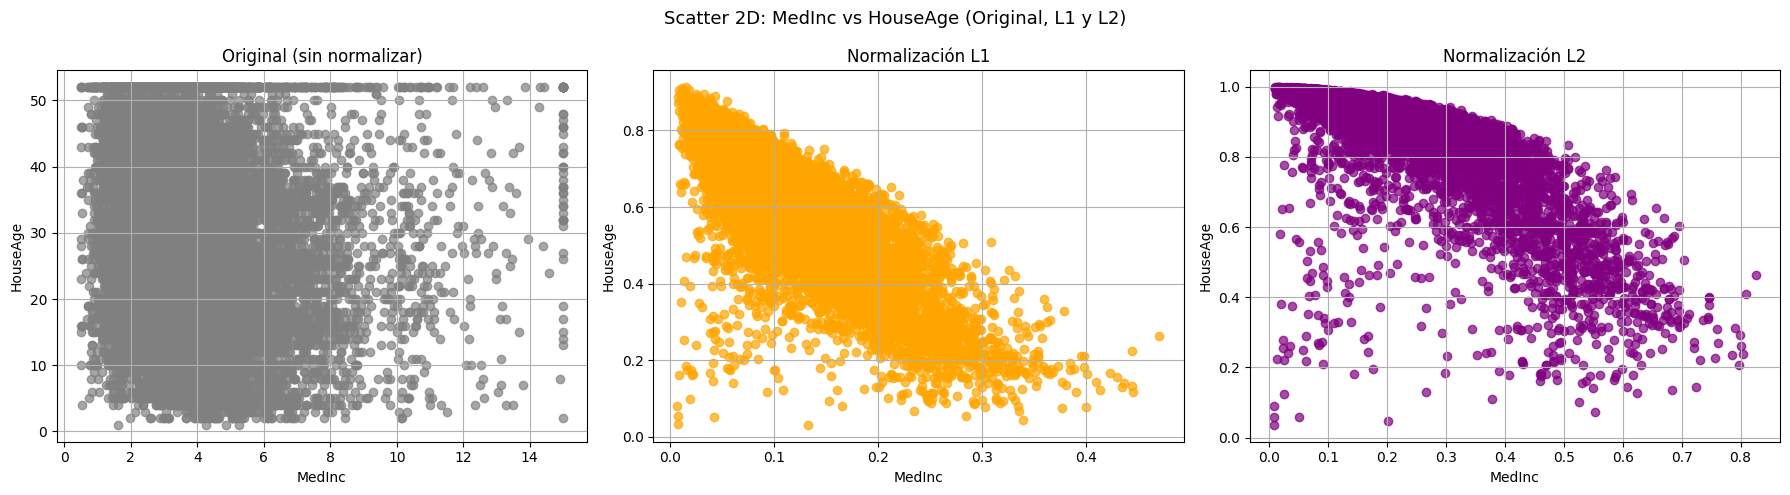

In [ ]:
# Gráfica 1: Scatter 2D - MedInc vs HouseAge (índices 0 y 1)
fig1, axs = plt.subplots(1, 3, figsize=(18, 5))

axs[0].scatter(X_np[:, 0], X_np[:, 1], color='gray', alpha=0.7)
axs[0].set_title('Original (sin normalizar)')
axs[0].set_xlabel(v[0])
axs[0].set_ylabel(v[1])
axs[0].grid(True)

axs[1].scatter(X_l1_np[:, 0], X_l1_np[:, 1], color='orange', alpha=0.7)
axs[1].set_title('Normalización L1')
axs[1].set_xlabel(v[0])
axs[1].set_ylabel(v[1])
axs[1].grid(True)

axs[2].scatter(X_l2_np[:, 0], X_l2_np[:, 1], color='purple', alpha=0.7)
axs[2].set_title('Normalización L2')
axs[2].set_xlabel(v[0])
axs[2].set_ylabel(v[1])
axs[2].grid(True)

plt.suptitle(f'Scatter 2D: {v[0]} vs {v[1]} (Original, L1 y L2)', fontsize=13)
plt.tight_layout()
plt.show()

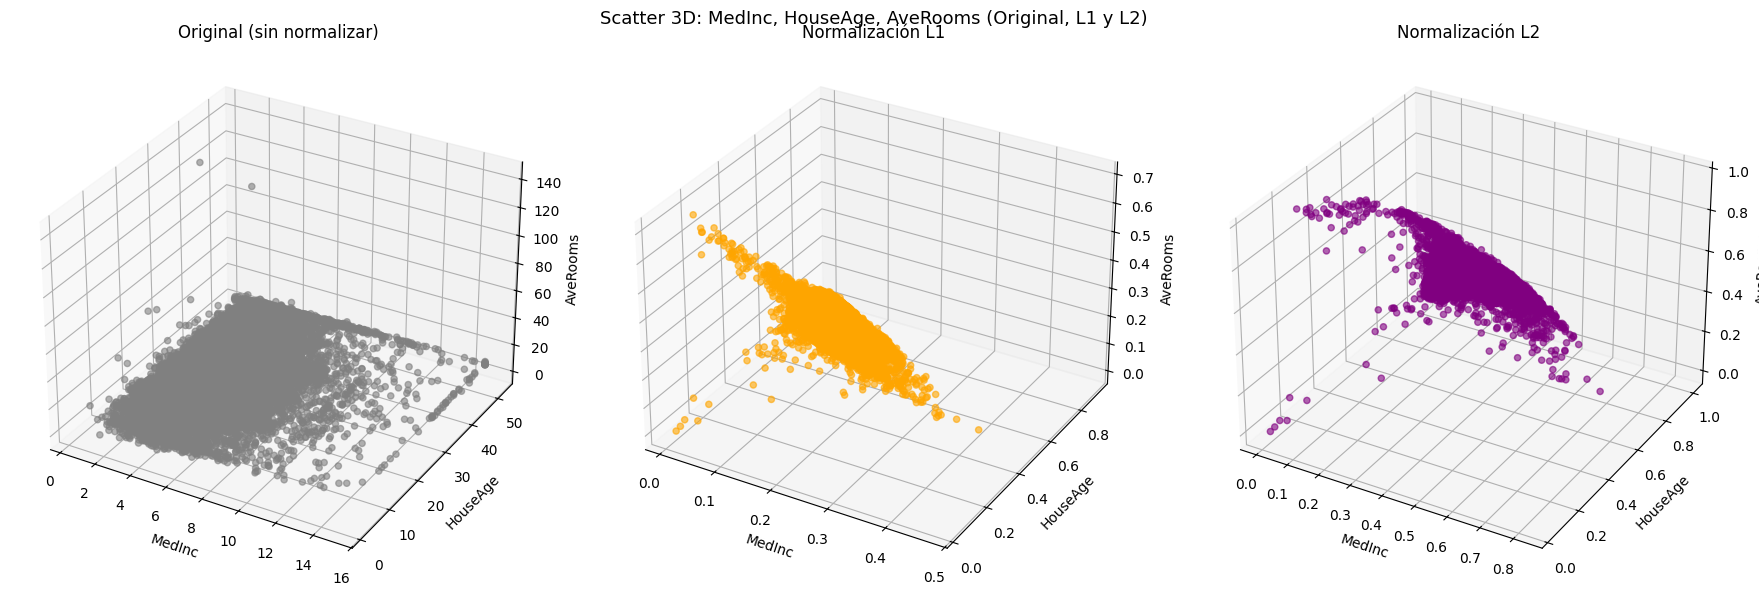

In [ ]:
# Gráfica 2: Scatter 3D - MedInc, HouseAge, AveRooms (índices 0,1,2)
fig2 = plt.figure(figsize=(18, 6))

ax1 = fig2.add_subplot(131, projection='3d')
ax1.scatter(X_np[:, 0], X_np[:, 1], X_np[:, 2], color='gray', alpha=0.6)
ax1.set_title('Original (sin normalizar)')
ax1.set_xlabel(v[0]); ax1.set_ylabel(v[1]); ax1.set_zlabel(v[2])

ax2 = fig2.add_subplot(132, projection='3d')
ax2.scatter(X_l1_np[:, 0], X_l1_np[:, 1], X_l1_np[:, 2], color='orange', alpha=0.6)
ax2.set_title('Normalización L1')
ax2.set_xlabel(v[0]); ax2.set_ylabel(v[1]); ax2.set_zlabel(v[2])

ax3 = fig2.add_subplot(133, projection='3d')
ax3.scatter(X_l2_np[:, 0], X_l2_np[:, 1], X_l2_np[:, 2], color='purple', alpha=0.6)
ax3.set_title('Normalización L2')
ax3.set_xlabel(v[0]); ax3.set_ylabel(v[1]); ax3.set_zlabel(v[2])

plt.suptitle(f'Scatter 3D: {v[0]}, {v[1]}, {v[2]} (Original, L1 y L2)', fontsize=13)
plt.tight_layout()
plt.show()

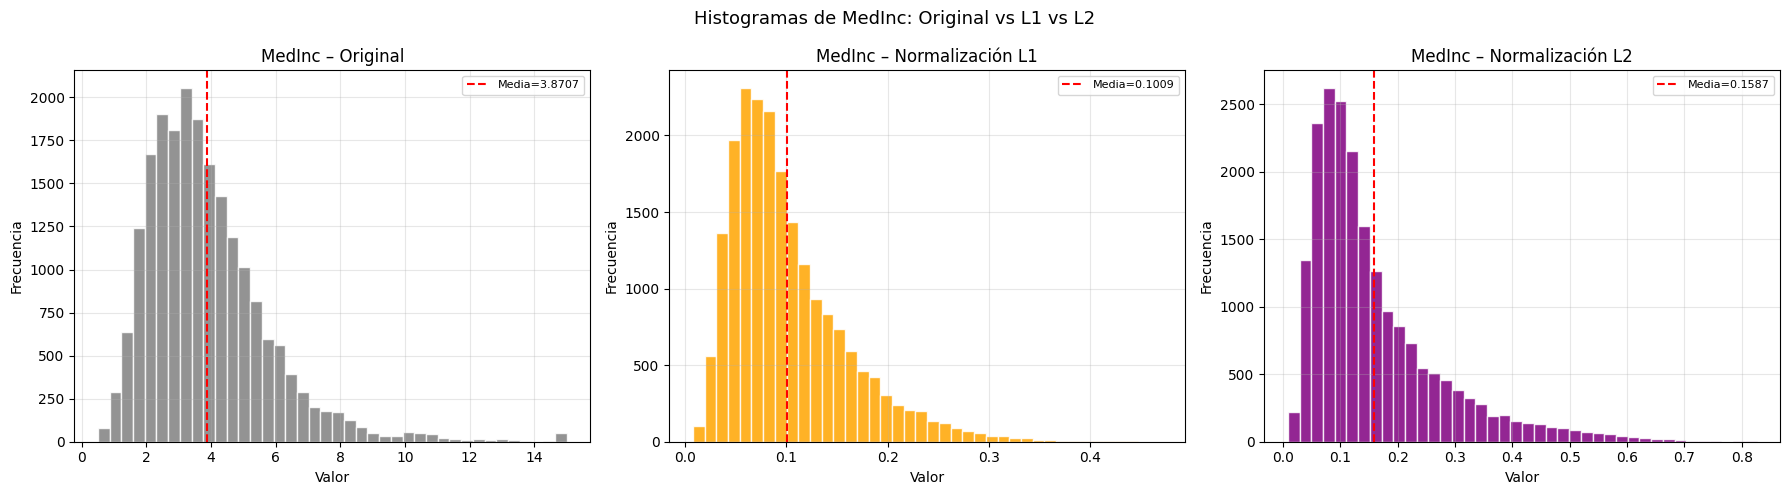

In [ ]:
# Gráfica 3: Histogramas de MedInc (Original, L1, L2)
fig3, axs3 = plt.subplots(1, 3, figsize=(18, 5))

configs = [
    (X_np[:, 0],    'Original',         'gray'),
    (X_l1_np[:, 0], 'Normalización L1', 'orange'),
    (X_l2_np[:, 0], 'Normalización L2', 'purple'),
]

for ax, (data, titulo, color) in zip(axs3, configs):
    ax.hist(data, bins=40, color=color, edgecolor='white', alpha=0.85)
    ax.axvline(data.mean(), color='red', linestyle='--', linewidth=1.5,
               label=f'Media={data.mean():.4f}')
    ax.set_title(f'{v[0]} – {titulo}')
    ax.set_xlabel('Valor')
    ax.set_ylabel('Frecuencia')
    ax.legend(fontsize=8)
    ax.grid(True, alpha=0.3)

plt.suptitle(f'Histogramas de {v[0]}: Original vs L1 vs L2', fontsize=13)
plt.tight_layout()
plt.show()

### **Análisis:**

Mientras L1 escala los valores de cada fila haciendo que la suma de los valores absolutos sea igual a 1, L2 los escala haciendo que la suma de los cuadrados sea igual a 1. En el dataset de `California Housing`, ambos métodos disminuyeron la escala de los valores (rango: 0 a 15 -> 0 a 0.4/0.7, dependiendo el método), a su vez comprimiendo la "nube" de datos dispersos logrando que se visualice una mejor distribución. Recomendaría usar L2, ya que no estamos trabajando con muchas variables, y a pesar de que estas no representan coordenadas, L2 ayuda a preservar mejor la estructura global de los datos, además de que las variables son continuas.

## **Ejercicio 4: Comparación de transformaciones para reducir asimetría**

**Dataset:** Diabetes (sklearn.datasets - load_diabetes)

**Variables seleccionadas:** `age`, `bmi`, `s2`, `s3`

### **Código:**

In [ ]:
# Cargar dataset
diabetes = load_diabetes(scaled=False)
df = pd.DataFrame(diabetes.data, columns=diabetes.feature_names)

print("Columnas disponibles:", list(df.columns))
print("\nPrimeras filas del dataset:")
print(df.head())
print("\nDescripción estadística general:")
print(df.describe())


"""
Nota: load_diabetes() escala los datos por defecto.
Se usa scaled=False para obtener los valores clínicos reales (todos positivos),
requisito necesario para aplicar np.log() y boxcox().
"""

Columnas disponibles: ['age', 'sex', 'bmi', 'bp', 's1', 's2', 's3', 's4', 's5', 's6']

Primeras filas del dataset:
    age  sex   bmi     bp     s1     s2    s3   s4      s5    s6
0  59.0  2.0  32.1  101.0  157.0   93.2  38.0  4.0  4.8598  87.0
1  48.0  1.0  21.6   87.0  183.0  103.2  70.0  3.0  3.8918  69.0
2  72.0  2.0  30.5   93.0  156.0   93.6  41.0  4.0  4.6728  85.0
3  24.0  1.0  25.3   84.0  198.0  131.4  40.0  5.0  4.8903  89.0
4  50.0  1.0  23.0  101.0  192.0  125.4  52.0  4.0  4.2905  80.0

Descripción estadística general:
              age         sex         bmi          bp          s1          s2  \
count  442.000000  442.000000  442.000000  442.000000  442.000000  442.000000   
mean    48.518100    1.468326   26.375792   94.647014  189.140271  115.439140   
std     13.109028    0.499561    4.418122   13.831283   34.608052   30.413081   
min     19.000000    1.000000   18.000000   62.000000   97.000000   41.600000   
25%     38.250000    1.000000   23.200000   84.000000  1

'\nNota: load_diabetes() escala los datos por defecto.\nSe usa scaled=False para obtener los valores clínicos reales (todos positivos),\nrequisito necesario para aplicar np.log() y boxcox().\n'

In [ ]:
# Selección de variables
variables = ['age', 'bmi', 's2', 's3']
X = df[variables].copy()

print(f"Variables seleccionadas: {variables}")
print("\nAsimetría por variable:")
for col in variables:
    print(f"  {col}: {skew(X[col]):.3f}")

Variables seleccionadas: ['age', 'bmi', 's2', 's3']

Asimetría por variable:
  age: -0.231
  bmi: 0.596
  s2: 0.435
  s3: 0.797


In [ ]:
# Transformaciones sobre la variable principal
var_principal = 'bmi'
x = X[var_principal].values

# Transformación logarítmica
x_log = np.log1p(x)

# Transformación logarítmica reflejada
x_reflected_log = np.log(np.max(x) - x + 1)

# Transformación cuadrática
x_squared = x ** 2

# Transformación Box-Cox
x_boxcox, lambda_bc = boxcox(x)

# Asimetría luego de cada transformación
print(f"Asimetría de '{var_principal}' antes y después de cada transformación:")
print(f"  Original:         {skew(x):.4f}")
print(f"  Log (log1p):      {skew(x_log):.4f}")
print(f"  Log reflejado:    {skew(x_reflected_log):.4f}")
print(f"  Cuadrática (x²):  {skew(x_squared):.4f}")
print(f"  Box-Cox (λ={lambda_bc:.3f}): {skew(x_boxcox):.4f}")

Asimetría de 'bmi' antes y después de cada transformación:
  Original:         0.5961
  Log (log1p):      0.2192
  Log reflejado:    -2.5700
  Cuadrática (x²):  1.0259
  Box-Cox (λ=-0.514): 0.0142


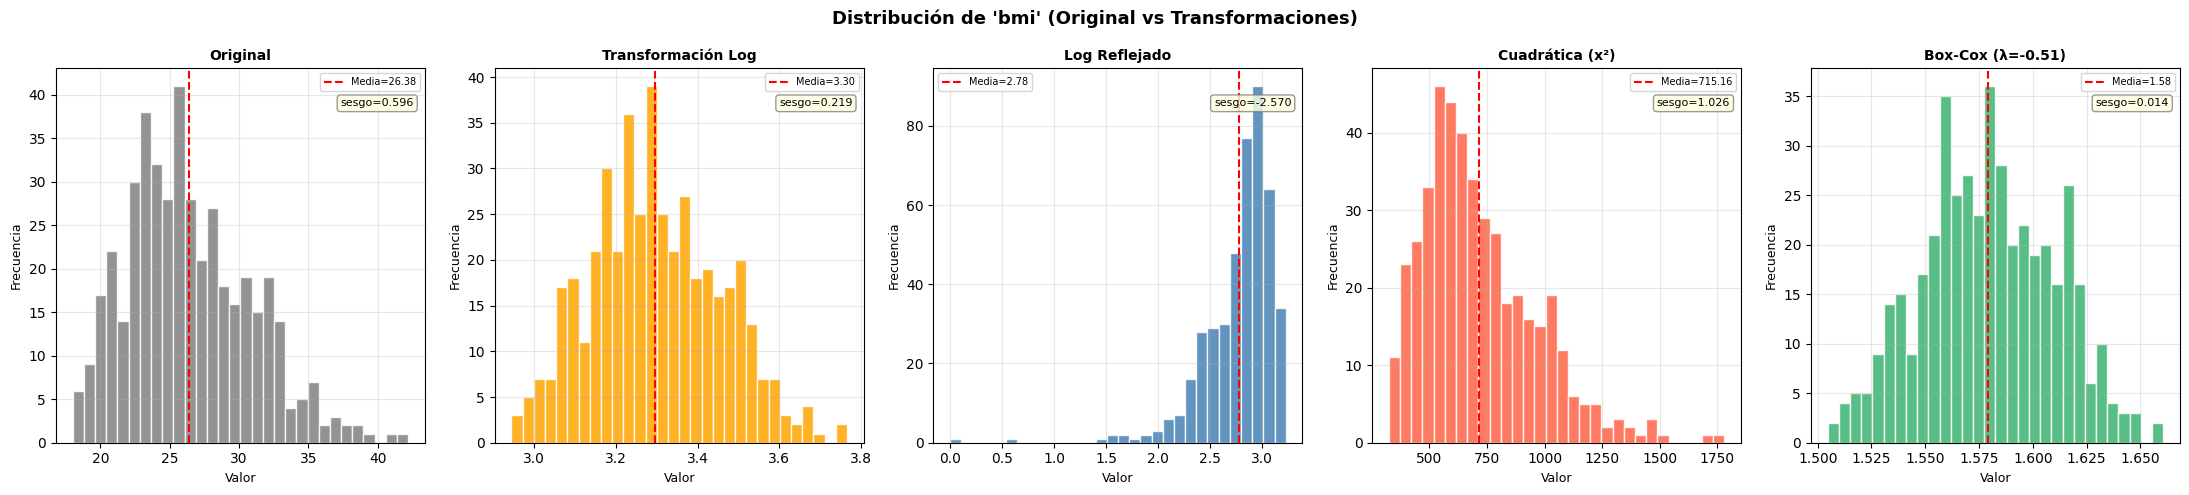

In [ ]:
# Gráfica 1: Histogramas comparativos
configs_hist = [
    (x,               'Original',           'gray'),
    (x_log,           'Transformación Log',  'orange'),
    (x_reflected_log, 'Log Reflejado',       'steelblue'),
    (x_squared,       'Cuadrática (x²)',     'tomato'),
    (x_boxcox,        f'Box-Cox (λ={lambda_bc:.2f})', 'mediumseagreen'),
]

fig1, axs1 = plt.subplots(1, 5, figsize=(22, 5))

for ax, (data, titulo, color) in zip(axs1, configs_hist):
    ax.hist(data, bins=30, color=color, edgecolor='white', alpha=0.85)
    ax.axvline(np.mean(data), color='red', linestyle='--', linewidth=1.5,
               label=f'Media={np.mean(data):.2f}')
    ax.set_title(titulo, fontsize=10, fontweight='bold')
    ax.set_xlabel('Valor', fontsize=9)
    ax.set_ylabel('Frecuencia', fontsize=9)
    ax.legend(fontsize=7)
    ax.text(0.97, 0.92, f'sesgo={skew(data):.3f}',
            transform=ax.transAxes, ha='right', va='top', fontsize=8,
            bbox=dict(boxstyle='round,pad=0.3', facecolor='lightyellow',
                      edgecolor='gray', alpha=0.8))
    ax.grid(True, alpha=0.3)

plt.suptitle(f"Distribución de '{var_principal}' (Original vs Transformaciones)",
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

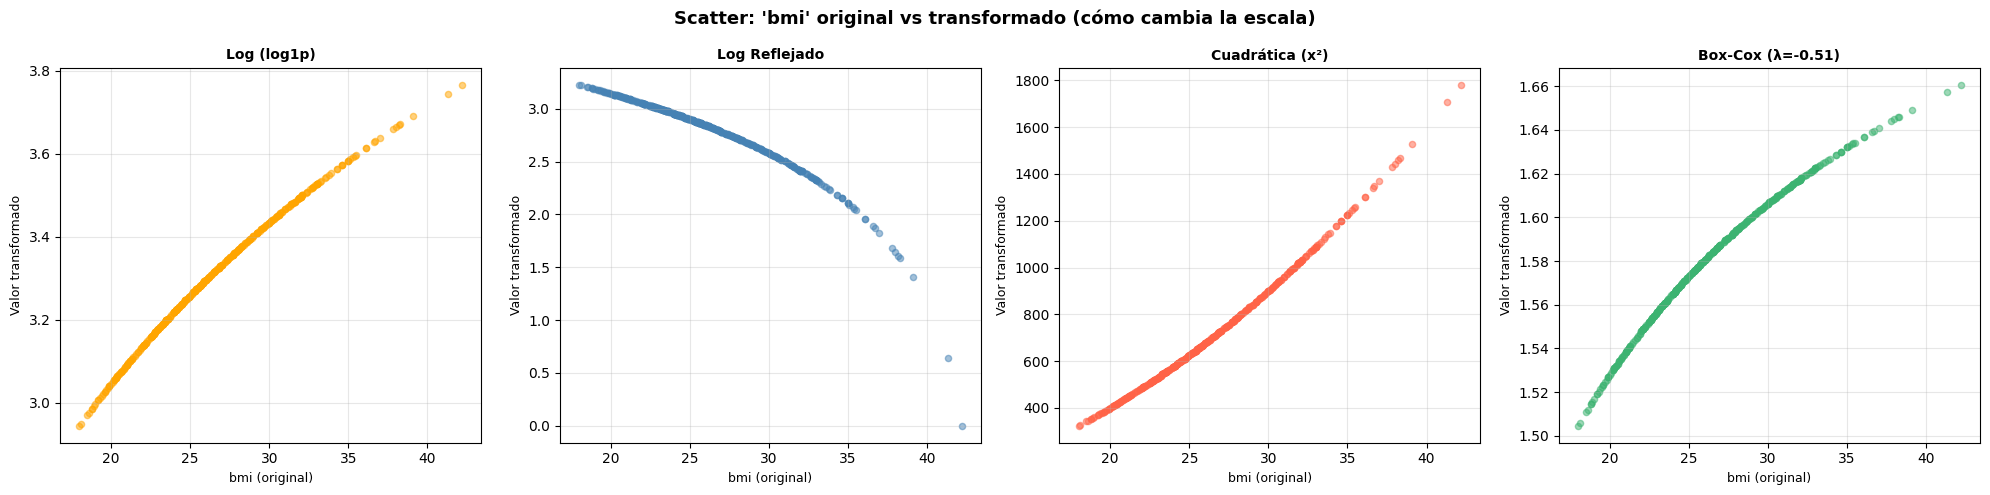

In [ ]:
# Gráfica 2: Scatter (Original vs cada transformación)
configs_scatter = [
    (x_log,           'Log (log1p)',         'orange'),
    (x_reflected_log, 'Log Reflejado',       'steelblue'),
    (x_squared,       'Cuadrática (x²)',     'tomato'),
    (x_boxcox,        f'Box-Cox (λ={lambda_bc:.2f})', 'mediumseagreen'),
]

fig2, axs2 = plt.subplots(1, 4, figsize=(20, 5))

for ax, (data_t, titulo, color) in zip(axs2, configs_scatter):
    ax.scatter(x, data_t, color=color, alpha=0.5, s=20)
    ax.set_xlabel(f'{var_principal} (original)', fontsize=9)
    ax.set_ylabel('Valor transformado', fontsize=9)
    ax.set_title(titulo, fontsize=10, fontweight='bold')
    ax.grid(True, alpha=0.3)

plt.suptitle(f"Scatter: '{var_principal}' original vs transformado (cómo cambia la escala)",
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

### **Análisis:**

La variable `bmi` presenta una asimetría positiva moderada (sesgo = 0.596), indicando una cola hacia la derecha. La transformación logarítmica redujo el sesgo a 0.219 comprimiendo los valores altos, mientras que Box-Cox lo redujo casi a cero al estimar automáticamente el mejor valor para su parámetro lambda. La transformación cuadrática empeoró el sesgo al amplificar las diferencias entre valores grandes, y el log reflejado lo invirtió ya que está diseñado para asimetría negativa, no positiva. Se recomienda Box-Cox por ser la más efectiva numéricamente y la más versátil, pues no necesita que se conozca previamente la dirección del sesgo.

## **Ejercicio 5: Comparación de transformaciones para reducir asimetría**

**Dataset:** Heart Disease (seaborn - load_dataset("heart"))

**Variables seleccionadas:** `chol`, `trestbps`, `thalach`, `oldpeak`

### **Código:**

In [ ]:
# Cargar dataset Heart Disease (seaborn v0.13 no incluye "heart" por defecto, se carga directamente desde UCI)

url = "https://archive.ics.uci.edu/ml/machine-learning-databases/heart-disease/processed.cleveland.data"

columnas = ['age', 'sex', 'cp', 'trestbps', 'chol', 'fbs',
            'restecg', 'thalach', 'exang', 'oldpeak', 'slope', 'ca', 'thal', 'target']

df = pd.read_csv(url, header=None, names=columnas, na_values='?')
df = df.dropna()  # eliminar los pocos registros con valores faltantes
df = df.astype(float)

print("Columnas disponibles:", list(df.columns))
print("\nPrimeras filas del dataset:")
print(df.head())
print("\nDescripción estadística general:")
print(df.describe())

Columnas disponibles: ['age', 'sex', 'cp', 'trestbps', 'chol', 'fbs', 'restecg', 'thalach', 'exang', 'oldpeak', 'slope', 'ca', 'thal', 'target']

Primeras filas del dataset:
    age  sex   cp  trestbps   chol  fbs  restecg  thalach  exang  oldpeak  \
0  63.0  1.0  1.0     145.0  233.0  1.0      2.0    150.0    0.0      2.3   
1  67.0  1.0  4.0     160.0  286.0  0.0      2.0    108.0    1.0      1.5   
2  67.0  1.0  4.0     120.0  229.0  0.0      2.0    129.0    1.0      2.6   
3  37.0  1.0  3.0     130.0  250.0  0.0      0.0    187.0    0.0      3.5   
4  41.0  0.0  2.0     130.0  204.0  0.0      2.0    172.0    0.0      1.4   

   slope   ca  thal  target  
0    3.0  0.0   6.0     0.0  
1    2.0  3.0   3.0     2.0  
2    2.0  2.0   7.0     1.0  
3    3.0  0.0   3.0     0.0  
4    1.0  0.0   3.0     0.0  

Descripción estadística general:
              age         sex          cp    trestbps        chol         fbs  \
count  297.000000  297.000000  297.000000  297.000000  297.000000  2

In [ ]:
variables = ['chol', 'trestbps', 'thalach', 'oldpeak']
X = df[variables].copy()

print(f"Variables seleccionadas: {variables}")
print("\nAsimetría por variable:")
for col in variables:
    print(f"  {col}: {skew(X[col].dropna()):.3f}")

Variables seleccionadas: ['chol', 'trestbps', 'thalach', 'oldpeak']

Asimetría por variable:
  chol: 1.112
  trestbps: 0.697
  thalach: -0.534
  oldpeak: 1.241


In [ ]:
# Transformaciones sobre la variable principal
var_principal = 'chol'
x = X[var_principal].dropna().values

# Raíz cuadrada
x_sqrt = np.sqrt(x)

# Recíproca
x_recip = 1 / (x + 1e-6)

# Yeo-Johnson
transformer = PowerTransformer(method='yeo-johnson', standardize=False)
x_yeojohnson = transformer.fit_transform(x.reshape(-1, 1)).flatten()

# Asimetría luego de cada transformación
print(f"Asimetría de '{var_principal}' antes y después de cada transformación:")
print(f"  Original:         {skew(x):.4f}")
print(f"  Raíz cuadrada:    {skew(x_sqrt):.4f}")
print(f"  Recíproca (1/x):  {skew(x_recip):.4f}")
print(f"  Yeo-Johnson:      {skew(x_yeojohnson):.4f}")

Asimetría de 'chol' antes y después de cada transformación:
  Original:         1.1124
  Raíz cuadrada:    0.5325
  Recíproca (1/x):  0.7867
  Yeo-Johnson:      -0.0043


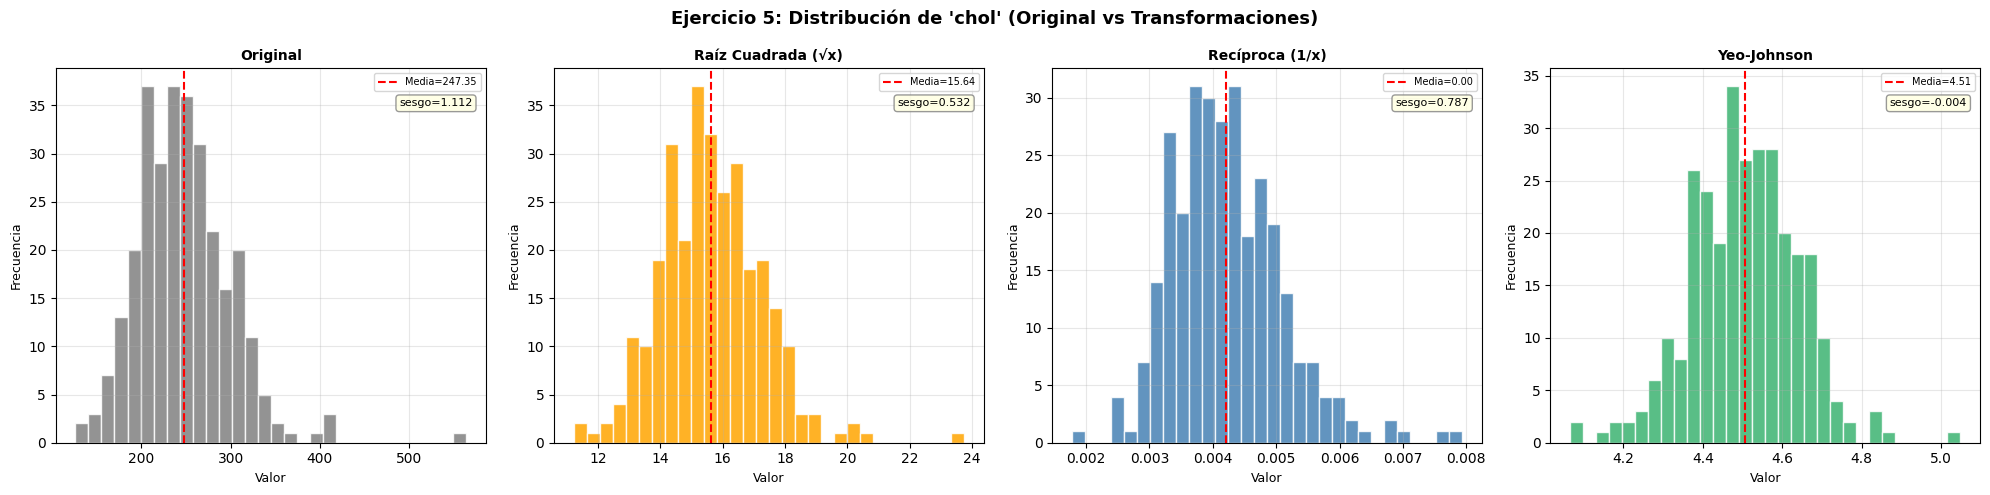

In [ ]:
# Gráfica 1: Histogramas comparativos
configs_hist = [
    (x,            'Original',              'gray'),
    (x_sqrt,       'Raíz Cuadrada (√x)',    'orange'),
    (x_recip,      'Recíproca (1/x)',        'steelblue'),
    (x_yeojohnson, 'Yeo-Johnson',            'mediumseagreen'),
]

fig1, axs1 = plt.subplots(1, 4, figsize=(20, 5))

for ax, (data, titulo, color) in zip(axs1, configs_hist):
    ax.hist(data, bins=30, color=color, edgecolor='white', alpha=0.85)
    ax.axvline(np.mean(data), color='red', linestyle='--', linewidth=1.5,
               label=f'Media={np.mean(data):.2f}')
    ax.set_title(titulo, fontsize=10, fontweight='bold')
    ax.set_xlabel('Valor', fontsize=9)
    ax.set_ylabel('Frecuencia', fontsize=9)
    ax.legend(fontsize=7)
    ax.text(0.97, 0.92, f'sesgo={skew(data):.3f}',
            transform=ax.transAxes, ha='right', va='top', fontsize=8,
            bbox=dict(boxstyle='round,pad=0.3', facecolor='lightyellow',
                      edgecolor='gray', alpha=0.8))
    ax.grid(True, alpha=0.3)

plt.suptitle(f"Ejercicio 5: Distribución de '{var_principal}' (Original vs Transformaciones)",
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

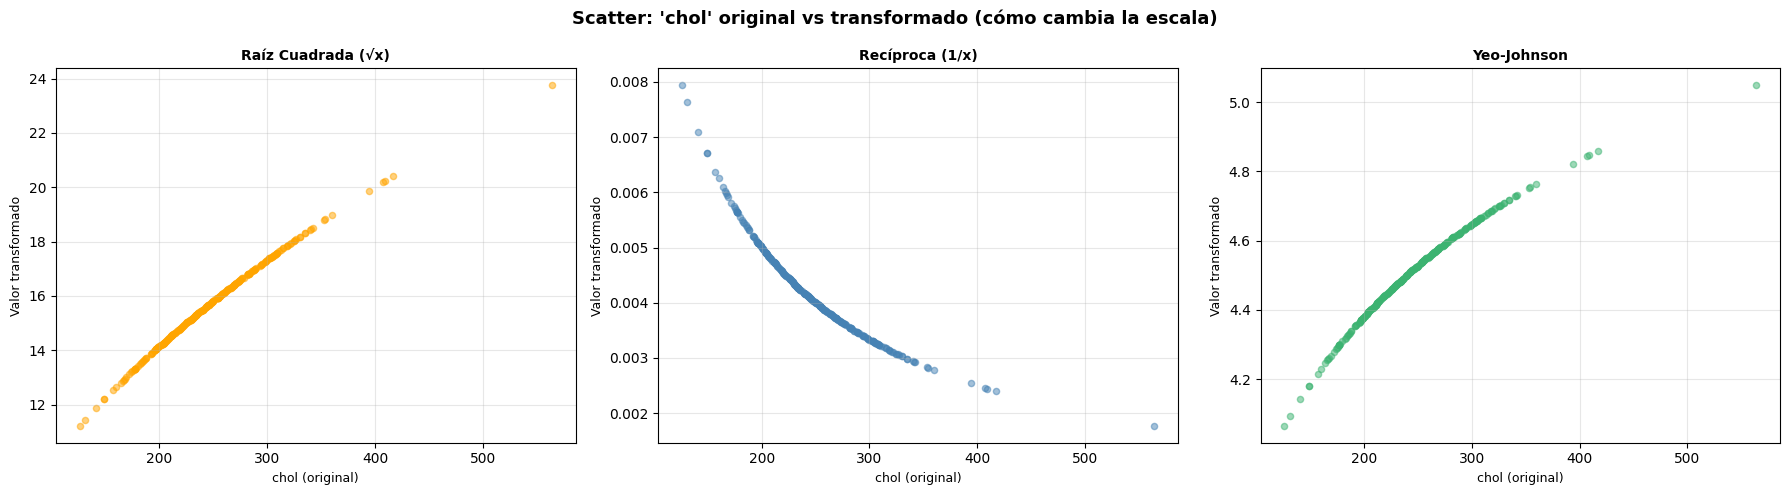

In [ ]:
# Gráfica 2: Scatter - Original vs cada transformación
configs_scatter = [
    (x_sqrt,       'Raíz Cuadrada (√x)',    'orange'),
    (x_recip,      'Recíproca (1/x)',        'steelblue'),
    (x_yeojohnson, 'Yeo-Johnson',            'mediumseagreen'),
]

fig2, axs2 = plt.subplots(1, 3, figsize=(18, 5))

for ax, (data_t, titulo, color) in zip(axs2, configs_scatter):
    ax.scatter(x, data_t, color=color, alpha=0.5, s=20)
    ax.set_xlabel(f'{var_principal} (original)', fontsize=9)
    ax.set_ylabel('Valor transformado', fontsize=9)
    ax.set_title(titulo, fontsize=10, fontweight='bold')
    ax.grid(True, alpha=0.3)

plt.suptitle(f"Scatter: '{var_principal}' original vs transformado (cómo cambia la escala)",
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

### **Análisis:**

La variable `chol` presenta una asimetría positiva moderada-alta (sesgo = 1.112), indicando una cola derecha con valores altos de colesterol. La raíz cuadrada redujo el sesgo a 0.532, mejorando un poco la simetría pero sin eliminarla completamente. La recíproca no logró mejorarlo significativamente (0.787) e invirtió la escala por completo, confirmando que es más efectiva con sesgos muy altos. Yeo-Johnson llevó el sesgo prácticamente a cero (-0.004). Se recomienda Yeo-Johnson porque no requiere datos estrictamente positivos, se adapta a cualquier distribución y estima automáticamente el mejor valor para el parámetro de transformación.